# Spaceship Titanic — Preprocesamiento de datos

**Materia:** Inteligencia Artificial Avanzada
**Equipo:** _(completar)_
**Integrantes:** _(completar)_
**Fecha:** _(completar)_

---

Este notebook cubre el pipeline de preparación de datos del reto
[Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic):
carga, EDA, selección de variables, manejo de faltantes, codificación,
transformación, escalado y verificación final.

Las celdas marcadas como **Interpretación** contienen el razonamiento del equipo
detrás de cada decisión; las celdas de código sólo generan la evidencia.

## 0. Configuración del entorno

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")  # oculta warnings para no ensuciar la salida

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)  # semilla fija para reproducibilidad

# Opciones de despliegue de pandas/matplotlib/seaborn
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)

# Los CSV viven en <repo>/data/spaceship-titanic/.
# Buscamos en varias rutas para que funcione tanto si ejecutas el notebook
# desde SpaceShip_Titanic/ como desde la raiz del repositorio.
CANDIDATAS = [
    Path("../data/spaceship-titanic"),
    Path("data/spaceship-titanic"),
    Path("data"),
]
DATA_DIR = next(
    (c for c in CANDIDATAS if (c / "train.csv").exists()),
    CANDIDATAS[0],
)  # primera ruta candidata que exista; si ninguna existe, usa la primera como default
print("DATA_DIR:", DATA_DIR.resolve())

print("pandas", pd.__version__, "| numpy", np.__version__)  # versiones para reproducibilidad

## 1. Carga y comprensión del dataset

In [ ]:
def obtener_datos(data_dir: Path = DATA_DIR) -> tuple[Path, Path]:
    """Devuelve las rutas de train.csv y test.csv.

    Intenta usar la copia local en data/; si no existe, descarga desde Kaggle
    con kagglehub (requiere credenciales y haber aceptado las reglas).
    """
    train_local, test_local = data_dir / "train.csv", data_dir / "test.csv"
    if train_local.exists() and test_local.exists():
        print("Usando copia local en", data_dir.resolve())
        return train_local, test_local

    # No hay copia local: se descarga el dataset de la competencia desde Kaggle
    import shutil

    import kagglehub

    ruta = Path(kagglehub.competition_download("spaceship-titanic"))
    for nombre in ("train.csv", "test.csv"):
        shutil.copy(ruta / nombre, data_dir / nombre)
    print("Descargado desde Kaggle y copiado a", data_dir.resolve())
    return train_local, test_local


ruta_train, ruta_test = obtener_datos()
train = pd.read_csv(ruta_train)  # dataset de entrenamiento (incluye el target)
test = pd.read_csv(ruta_test)  # dataset de prueba (sin target, para predecir)

print("train:", train.shape, "| test:", test.shape)

In [ ]:
train.head()  # primeras filas para inspeccion visual rapida

In [ ]:
train.info()  # tipos de dato y conteo de no-nulos por columna

In [ ]:
# Confirma tamanios y que la unica diferencia de columnas entre train y test sea el target
print("train shape:", train.shape)
print("test shape:", test.shape)

cols_train = set(train.columns)
cols_test = set(test.columns)
print("Columnas en train pero no en test:", cols_train - cols_test)
print("Columnas en test pero no en train:", cols_test - cols_train)

In [ ]:
train.describe()  # estadisticos descriptivos de las columnas numericas

In [ ]:
train.describe(include="object")  # conteo, cardinalidad y valor mas frecuente de las columnas categoricas

In [ ]:
train["Transported"].value_counts(normalize=True)  # proporcion de cada clase del target

### Interpretación — variable target y tipo de problema

La variable target del dataset es `Transported`, de tipo booleano (`True`/`False`), que indica si el pasajero fue transportado a otra dimensión durante el accidente. Al tratarse de una variable con únicamente dos valores posibles, el problema es de **clasificación binaria**.

Al revisar la distribución de clases con `value_counts(normalize=True)` se obtiene un balance de 50.4% para `True` y 49.6% para `False`. Las clases están prácticamente balanceadas, por lo que no se requiere ningún tratamiento especial de desbalance (como *class weights* o técnicas de *resampling*) más adelante en el pipeline.

Por su parte, `test.csv` cuenta con una columna menos que `train.csv`: justamente `Transported`. Esto se debe a que `test.csv` es el conjunto sobre el que se generarán las predicciones nuevas del modelo, simulando la situación real en la que el resultado todavía no se conoce. Kaggle oculta esa columna en su propio servidor para poder evaluar las predicciones del equipo contra los valores reales una vez enviadas.

## 2. Análisis exploratorio (EDA)

### 2.1 Faltantes: informativos vs. reales

In [18]:
# Porcentaje de valores faltantes por columna, solo las que tienen al menos un faltante
faltantes_pct = train.isna().mean().sort_values(ascending=False) * 100
faltantes_pct = faltantes_pct[faltantes_pct > 0]
faltantes_pct

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
dtype: float64

In [19]:
# Estadisticos de gasto para pasajeros con CryoSleep=True: si la logica del dominio se cumple, deberia ser todo 0
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train.loc[train["CryoSleep"] == True, spend_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,2969.0,2967.0,2941.0,2972.0,2975.0
mean,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0


In [20]:
# Estadisticos de gasto para pasajeros con CryoSleep=False: aqui si esperamos ver gasto real y su dispersion
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train.loc[train["CryoSleep"] == False, spend_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,5328.000000,5329.000000,5335.000000,5326.000000,5320.000000
mean,350.146772,713.004316,270.586504,486.092940,475.716165
std,803.080320,1970.547985,741.756155,1396.233751,1404.174304
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,5.000000,2.000000,7.000000,4.000000
75%,390.250000,537.000000,242.000000,354.750000,356.000000
max,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [21]:
# Gasto total (suma de las 5 columnas) agrupado por CryoSleep, para comparar el patron entre True y False
train.assign(TotalSpend=train[spend_cols].sum(axis=1)).groupby("CryoSleep")["TotalSpend"].describe()

,count,mean,std,min,25%,50%,75%,max
CryoSleep,,,,,,,,
False,5439.0,2248.299687,3245.061489,0.0,746.0,1019.0,2416.0,35987.0
True,3037.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [22]:
# PassengerId tiene formato gggg_pp (grupo_persona); extraemos el grupo de viaje
train["Group"] = train["PassengerId"].str.split("_").str[0]

# Cuantas personas viajan juntas en el mismo grupo (tamano de cada grupo)
train.groupby("Group").size().value_counts().sort_index()

1    4805
2     841
3     340
4     103
5      53
6      29
7      33
8      13
Name: count, dtype: int64

In [23]:
# Por grupo, cuantos valores distintos de HomePlanet hay (sin contar nulos)
# Si el resultado es casi siempre 1, el grupo comparte planeta de origen
homeplanet_por_grupo = train.groupby("Group")["HomePlanet"].nunique(dropna=True)
homeplanet_por_grupo.value_counts().sort_index()

HomePlanet
0     110
1    6107
Name: count, dtype: int64

In [24]:
# Extraemos el Deck (primera parte de Cabin, formato deck/num/side)
train["Deck"] = train["Cabin"].str.split("/").str[0]

# Por grupo, cuantos Decks distintos hay (sin contar nulos)
deck_por_grupo = train.groupby("Group")["Deck"].nunique(dropna=True)
deck_por_grupo.value_counts().sort_index()

Deck
0      99
1    5697
2     400
3      21
Name: count, dtype: int64

#### Interpretación — clasificación de faltantes

Para **cada** columna con faltantes (la tabla de `faltantes_pct`), clasifíquenla como *informativo* o *real*, con evidencia:

1. ¿Qué porcentaje de faltantes tiene cada columna? ¿Son similares entre sí o hay alguna muy distinta al resto? (un patrón muy uniforme entre columnas sugiere faltantes inyectados al azar, no informativos).
2. Con la evidencia de las dos celdas anteriores: cuando `CryoSleep=True`, ¿cuánto gastan los pasajeros en promedio? ¿Y cuando es `False`? ¿Qué les dice esto sobre imputar los gastos faltantes según el valor de `CryoSleep`?
3. Para el resto de las columnas (`HomePlanet`, `Cabin`, `Destination`, `VIP`, `Name`, `Age`), ¿encuentran alguna relación lógica similar con otra variable, o su ausencia parece simplemente aleatoria? Justifiquen columna por columna, no en bloque.

### 2.2 Variables numéricas: distribución, skewness y outliers

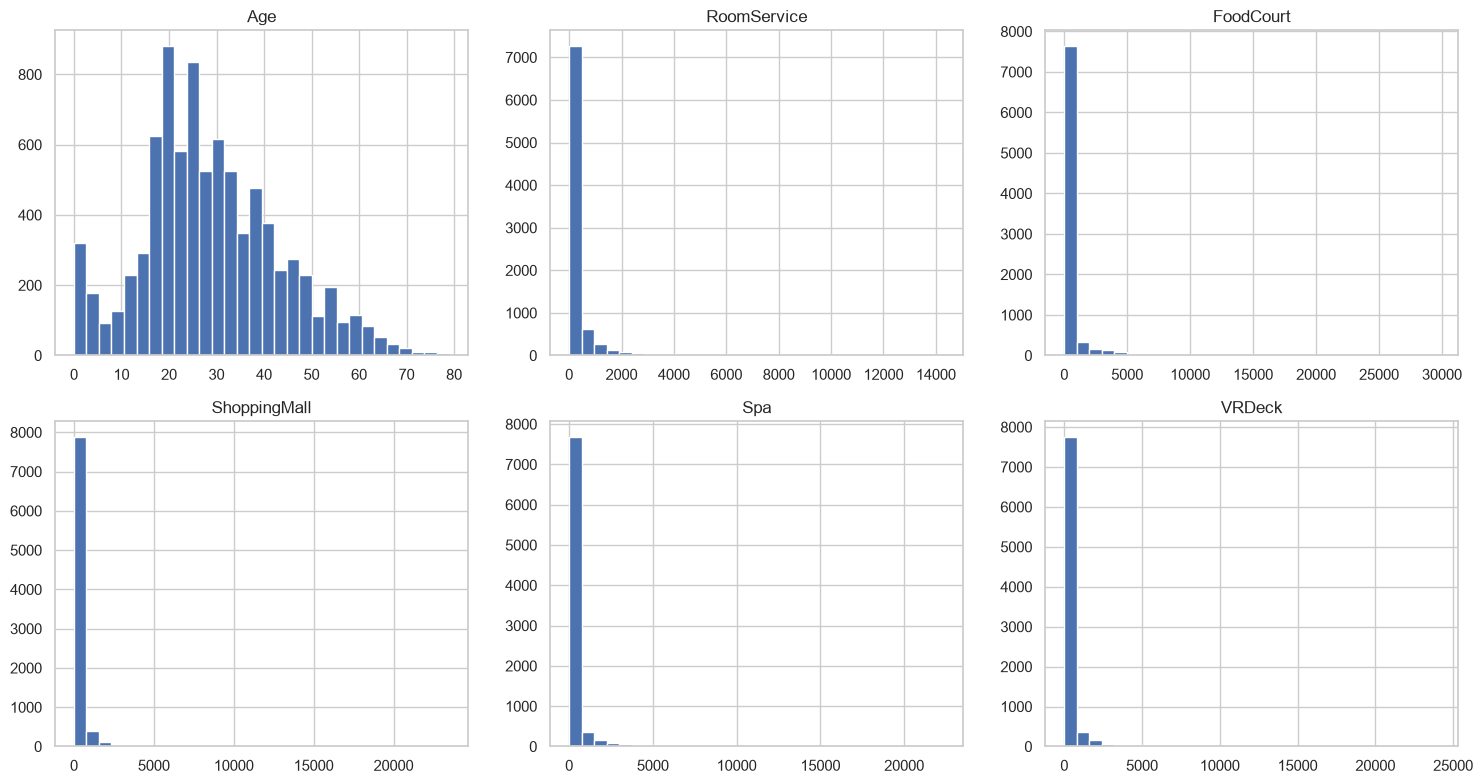

In [25]:
# Columnas numericas continuas del dataset (Transported es el target booleano, no entra aqui)
numeric_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    train[col].hist(bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [26]:
# Skewness (asimetria) de cada variable numerica: cerca de 0 = simetrica, >1 o <-1 = sesgo fuerte
train[numeric_cols].skew().sort_values(ascending=False)

ShoppingMall    12.627562
VRDeck           7.819732
Spa              7.636020
FoodCourt        7.102228
RoomService      6.333014
Age              0.419097
dtype: float64

In [27]:
# Deteccion de outliers con la regla de Tukey / IQR: fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
def resumen_outliers_iqr(df, cols):
    filas = []
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        filas.append({
            "columna": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": lim_inf,
            "limite_superior": lim_sup,
            "n_outliers": n_outliers,
            "pct_outliers": 100 * n_outliers / df[col].notna().sum(),
        })
    return pd.DataFrame(filas)


resumen_outliers_iqr(train, numeric_cols)

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.904393
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.863252
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,21.421857
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.555687
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,21.010576
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,21.269841


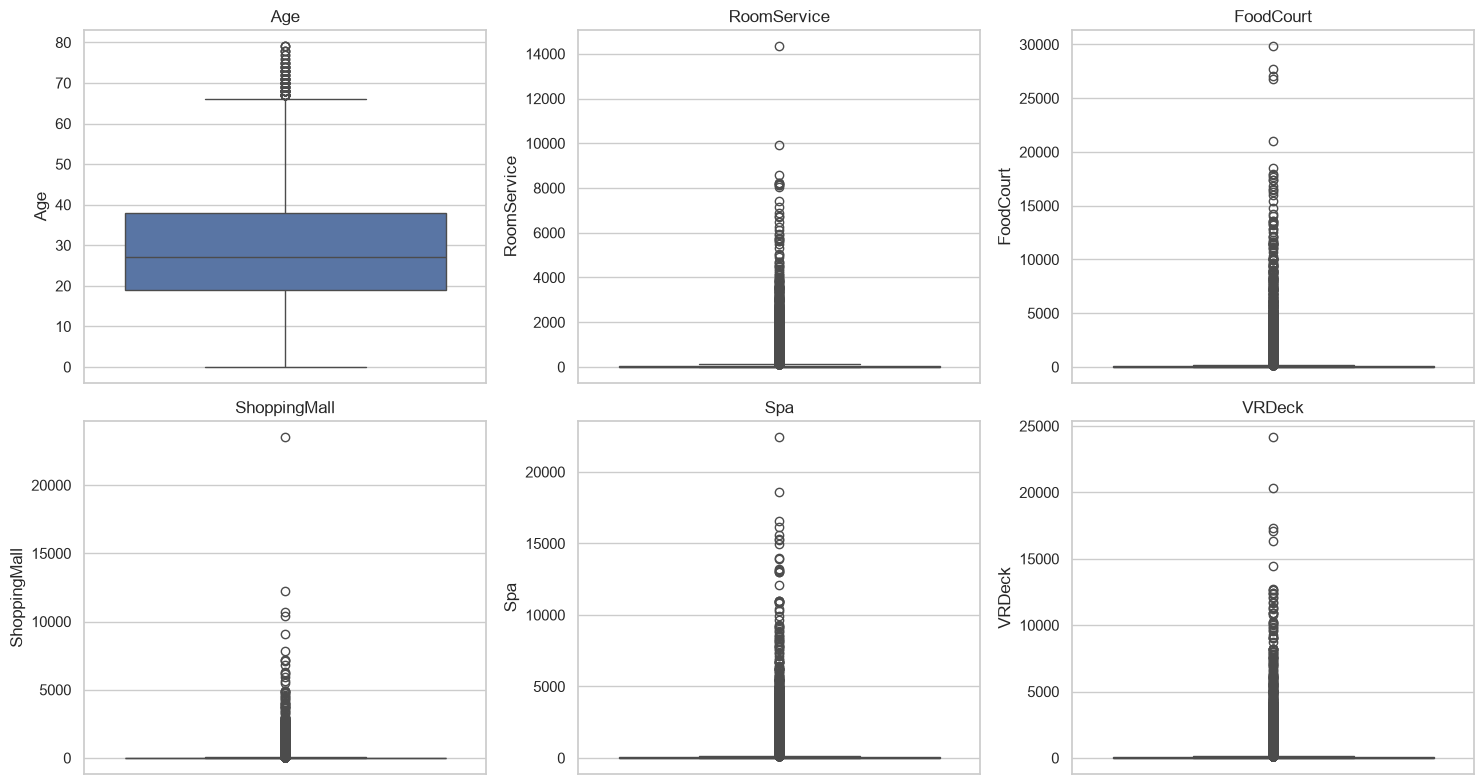

In [28]:
# Boxplots para visualizar dispersion y outliers de cada variable numerica
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(y=train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — distribución, skewness y outliers

Respondan con base en los histogramas, `skew()` y la tabla de outliers de arriba:

1. ¿Qué variables tienen sesgo (skewness) alto y en qué dirección (positivo/negativo)? ¿Cuál es prácticamente simétrica?
2. Según la tabla de outliers (regla de Tukey/IQR), ¿qué columnas tienen mayor porcentaje de outliers?
3. Muchas filas de las columnas de gasto valen exactamente 0 (pasajeros en `CryoSleep` o que no gastaron). ¿Los "outliers" detectados por IQR son errores de captura o son valores legítimos de pasajeros que gastaron mucho? Justifiquen si tiene sentido tratarlos como errores a eliminar o como información válida.
4. Con esta evidencia, ¿qué tipo de transformación anticipan que necesitarán en la sección 6 para las columnas más sesgadas?

### 2.3 Variables categóricas: cardinalidad y desbalance

In [29]:
# Cardinalidad (numero de valores unicos) de cada columna categorica, incluyendo Deck y Group derivadas
cat_cols_all = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "VIP", "Name", "Deck", "Group"]
train[cat_cols_all].nunique().sort_values(ascending=False)

Name           8473
Cabin          6560
Group          6217
Deck              8
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
dtype: int64

In [30]:
# Distribucion de categorias (proporcion) para las columnas de baja cardinalidad
cat_cols_baja_card = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck"]
for col in cat_cols_baja_card:
    print(f"--- {col} ---")
    print(train[col].value_counts(normalize=True, dropna=False))
    print()

--- HomePlanet ---
HomePlanet
Earth     0.529391
Europa    0.245140
Mars      0.202347
NaN       0.023122
Name: proportion, dtype: float64

--- CryoSleep ---
CryoSleep
False    0.625676
True     0.349362
NaN      0.024963
Name: proportion, dtype: float64

--- Destination ---
Destination
TRAPPIST-1e      0.680433
55 Cancri e      0.207063
PSO J318.5-22    0.091568
NaN              0.020936
Name: proportion, dtype: float64

--- VIP ---
VIP
False    0.953756
NaN      0.023352
True     0.022892
Name: proportion, dtype: float64

--- Deck ---
Deck
F      0.321408
G      0.294375
E      0.100771
B      0.089612
C      0.085931
D      0.054987
A      0.029449
NaN    0.022892
T      0.000575
Name: proportion, dtype: float64



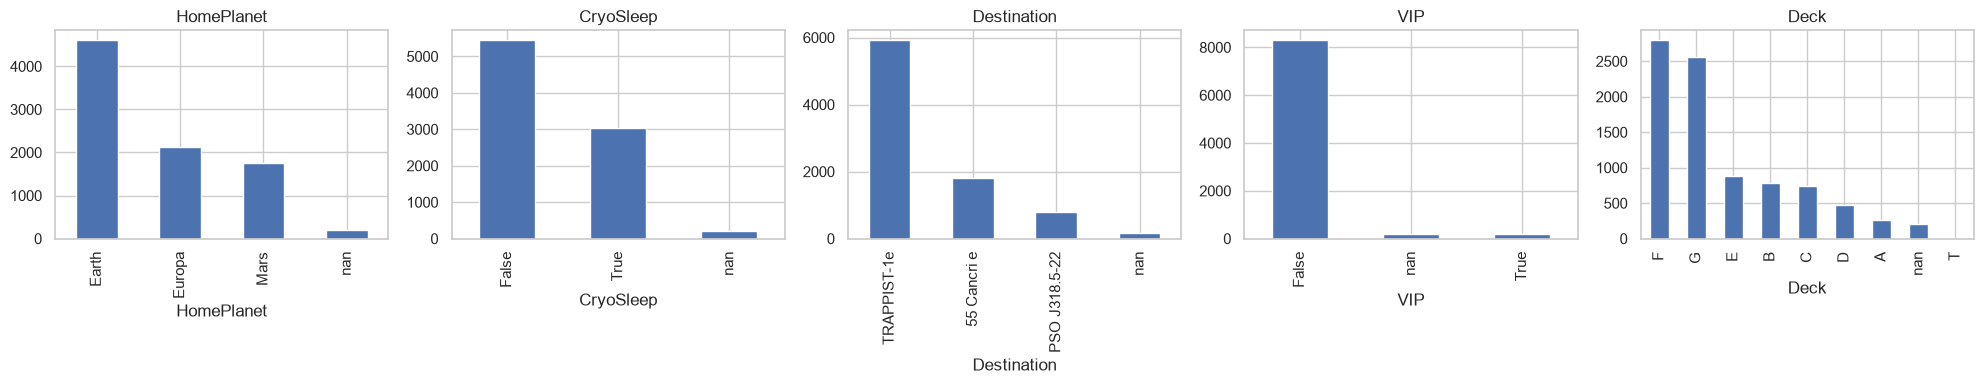

In [31]:
# Grafico de barras de la distribucion de cada columna de baja cardinalidad
fig, axes = plt.subplots(1, len(cat_cols_baja_card), figsize=(4 * len(cat_cols_baja_card), 4))
for col, ax in zip(cat_cols_baja_card, axes):
    train[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — cardinalidad y desbalance

Respondan con base en la tabla de cardinalidad, los `value_counts` y los gráficos de arriba:

1. ¿Qué columnas tienen cardinalidad muy alta (`Name`, `Cabin`, `Group`)? ¿Se pueden usar tal cual como variable categórica en un modelo, o hay que transformarlas/descartarlas?
2. ¿Alguna columna de baja cardinalidad muestra desbalance extremo (una categoría con proporción muy dominante, ej. >90%)?
3. Para las columnas con desbalance extremo que encuentren: ¿tendría más sentido binarizarlas (por ejemplo, crear una columna `Is_X` que indique la categoría minoritaria) en vez de descartarlas directamente? Justifiquen con la evidencia de la distribución.
4. `Deck` (derivada de `Cabin`) tiene varias categorías con muy pocos casos — ¿alguna de ellas es candidata a agruparse en una categoría "Otros" antes de codificar?

### 2.4 Relación de cada variable con el target

In [32]:
# Crosstab de cada categorica de baja cardinalidad contra el target, normalizado por fila
# (proporcion de Transported=True/False dentro de cada categoria)
for col in cat_cols_baja_card:
    print(f"--- {col} vs Transported ---")
    print(pd.crosstab(train[col], train["Transported"], normalize="index"))
    print()

--- HomePlanet vs Transported ---
Transported     False     True 
HomePlanet                     
Earth        0.576054  0.423946
Europa       0.341154  0.658846
Mars         0.476976  0.523024

--- CryoSleep vs Transported ---
Transported     False     True 
CryoSleep                      
False        0.671079  0.328921
True         0.182417  0.817583

--- Destination vs Transported ---
Transported       False     True 
Destination                      
55 Cancri e    0.390000  0.610000
PSO J318.5-22  0.496231  0.503769
TRAPPIST-1e    0.528825  0.471175

--- VIP vs Transported ---
Transported     False     True 
VIP                            
False        0.493668  0.506332
True         0.618090  0.381910

--- Deck vs Transported ---
Transported     False     True 
Deck                           
A            0.503906  0.496094
B            0.265725  0.734275
C            0.319946  0.680054
D            0.566946  0.433054
E            0.642694  0.357306
F            0.560129  0.4398

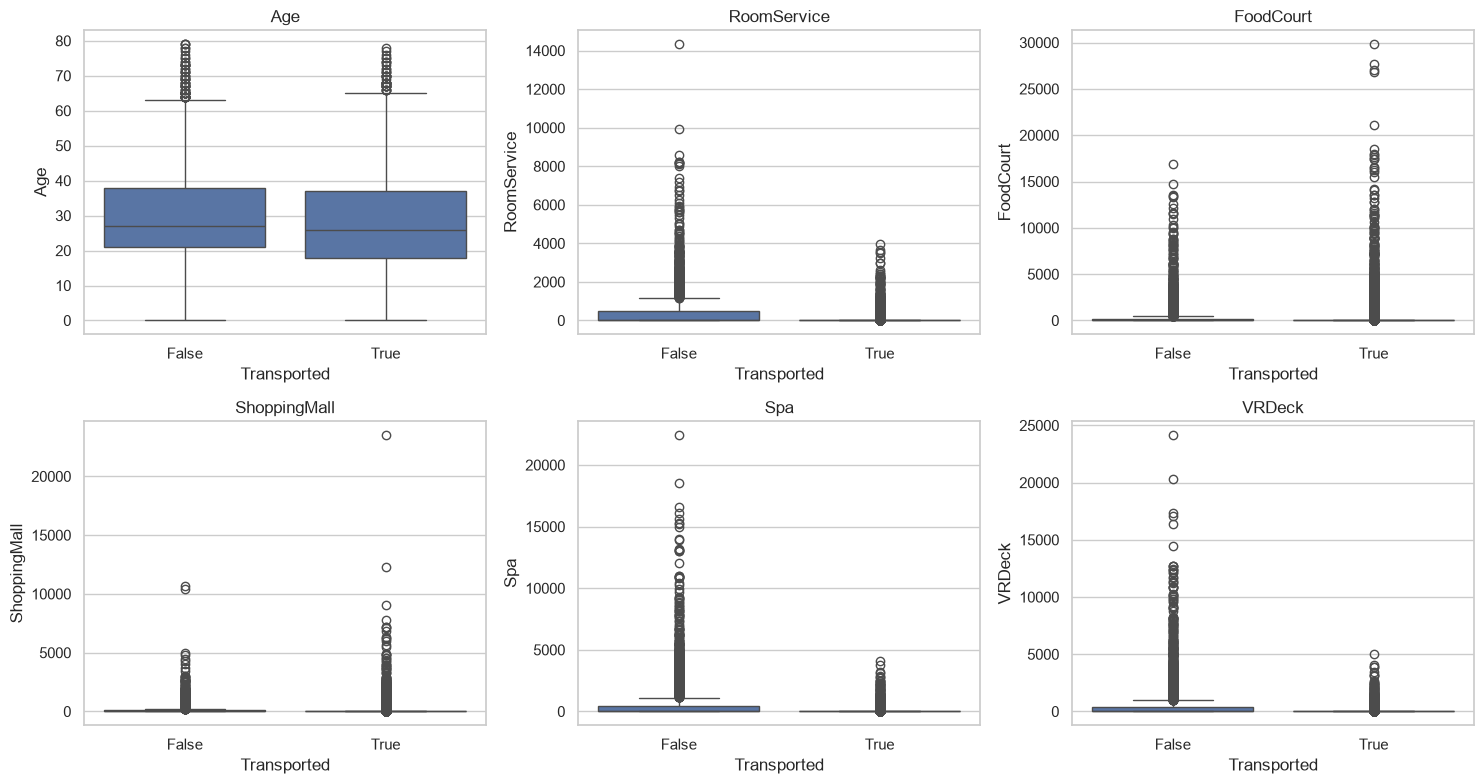

In [33]:
# Boxplots de cada variable numerica separando por el valor del target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(x="Transported", y=col, data=train, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — relación de cada variable con el target

Respondan con base en los crosstabs y los boxplots de arriba:

1. Para cada categórica (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Deck`), ¿qué categorías muestran una proporción de `Transported=True` claramente distinta al 50/50 general? ¿Cuáles parecen más predictivas y cuáles casi no diferencian?
2. Para cada numérica, ¿la mediana o el rango cambia visiblemente entre `Transported=True` y `Transported=False` en el boxplot, o las distribuciones se ven casi iguales?
3. Con esta evidencia (2.1 a 2.4 completos), ¿qué variables se perfilan ya como candidatas fuertes para el modelo, y cuáles como candidatas a descartar o transformar? Esto es la base directa de la sección 3.

## 3. Selección y descarte de variables

In [ ]:
# Tabla resumen de todas las columnas: tipo de dato, % de faltantes y cardinalidad
# Sirve como referencia rapida para decidir que variable entra o sale del pipeline
resumen_variables = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "pct_faltantes": (train.isna().mean() * 100).round(2),
    "cardinalidad": train.nunique(),
})
resumen_variables.sort_values("pct_faltantes", ascending=False)

In [ ]:
# Proporcion de la categoria mas frecuente en cada columna categorica de baja cardinalidad
# Un valor cercano a 1.0 (ej. >0.90) indica desbalance extremo
for col in cat_cols_baja_card:
    top_prop = train[col].value_counts(normalize=True, dropna=False).iloc[0]
    categoria_top = train[col].value_counts(normalize=True, dropna=False).idxmax()
    print(f"{col}: categoria mas frecuente = {categoria_top!r} ({top_prop:.2%})")

### Interpretación — selección y descarte de variables

Decidan, **columna por columna**, si entra al pipeline, se transforma antes de entrar, o se descarta — con evidencia de las secciones 2.1 a 2.4 (porcentaje de faltantes, cardinalidad, desbalance, relación con el target):

1. **Identificadores y texto libre** (`PassengerId`, `Name`) — ¿aportan como feature directa, o solo sirven para derivar otras columnas (como `Group`) y luego se descartan?
2. **Alta cardinalidad** (`Cabin`, `Group`) — ¿se usan tal cual, o ya fueron reemplazadas por versiones más manejables (`Deck`, tamaño de grupo)? Justifiquen con la cardinalidad de la tabla resumen.
3. **Categóricas de baja cardinalidad** (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Deck`) — según los crosstabs de 2.4, ¿cuáles muestran relación clara con `Transported` y cuáles casi no diferencian? Para las que tengan desbalance extremo (revisen la celda anterior), ¿conviene binarizar en vez de descartar? Den un ejemplo concreto si aplica.
4. **Numéricas** (`Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) — ¿se quedan las 5 columnas de gasto por separado, se combinan en una sola (ej. `TotalSpend`), o ambas cosas? Justifiquen con lo visto en 2.2 y 2.4.
5. Cierre: hagan una lista final de variables incluidas vs. descartadas (puede ser una tabla simple aquí mismo), cada una con una justificación de una línea.

## 4. Manejo de faltantes

## 5. Codificación de variables categóricas

## 6. Transformación de variables numéricas

## 7. Escalado

## 8. Verificación final

### 8.1 Tabla resumen de decisiones

### 8.2 Conclusión

---

## Nota de uso de IA

_(completar)_